# Assignment 3 $-$ Argument Mining
_Solutions have to be submitted in pairs of two by Monday, June 1st, 23:59 (UTC+2)._

**Grading:**

This assignment is worth 30 points, which you earn through running code without unhandled, preventable errors, correct outputs, and answers to analysis questions
- **0 - *Fail*:** No submission; non-working code (preventable errors and exceptions); code that directly contradicts the task description or produces incorrect outputs; authorship violations like plagiarism or solutions fully or largely generated by AI

**Submission Components:**

- **Code:** Tasks 1 and 2
  - **Output Files:** Your submission should include the output files in the correct folder with the correct naming.
  - **Explanation:** You should add overall explanations of your code (i.e., modify/employ docstrings) and comments for individual implementation decisions.
- **Analysis:** Task 3 answered in full text with sensible formatting and using the results from task 2 explicitly.

**Submission Group:**
YOUR ANSWER HERE

In [ ]:
# As you train a neural model, you need access to a GPU:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("GPU is available:", torch.cuda.is_available())

## Introduction
### General Description

Develop an approach to the task of relation detection between two claims $p_1$ and $p_2$, i.e, determining wether:
- $p_1$ is a _premise_ supporting or attacking _claim_ $p_2$
- $p_1$ and $p_2$ are unrelated

Train a transformer-architecture neural network on the task and analyze the resulting embedding space.

### Learning Goals
- Train a neural model
- Interpret model performance

### Topics Covered
- Siamese Network Architecture and triplet loss
- Extracting task-specific features
- Quantitative and qualitative error analysis

## Contrastive Learning
### General Idea
Learning embeddings such that _similar data sample pairs_ are close while _dissimilar sample pair_ stay far apart  (Chopra et al., 2005$^1$):

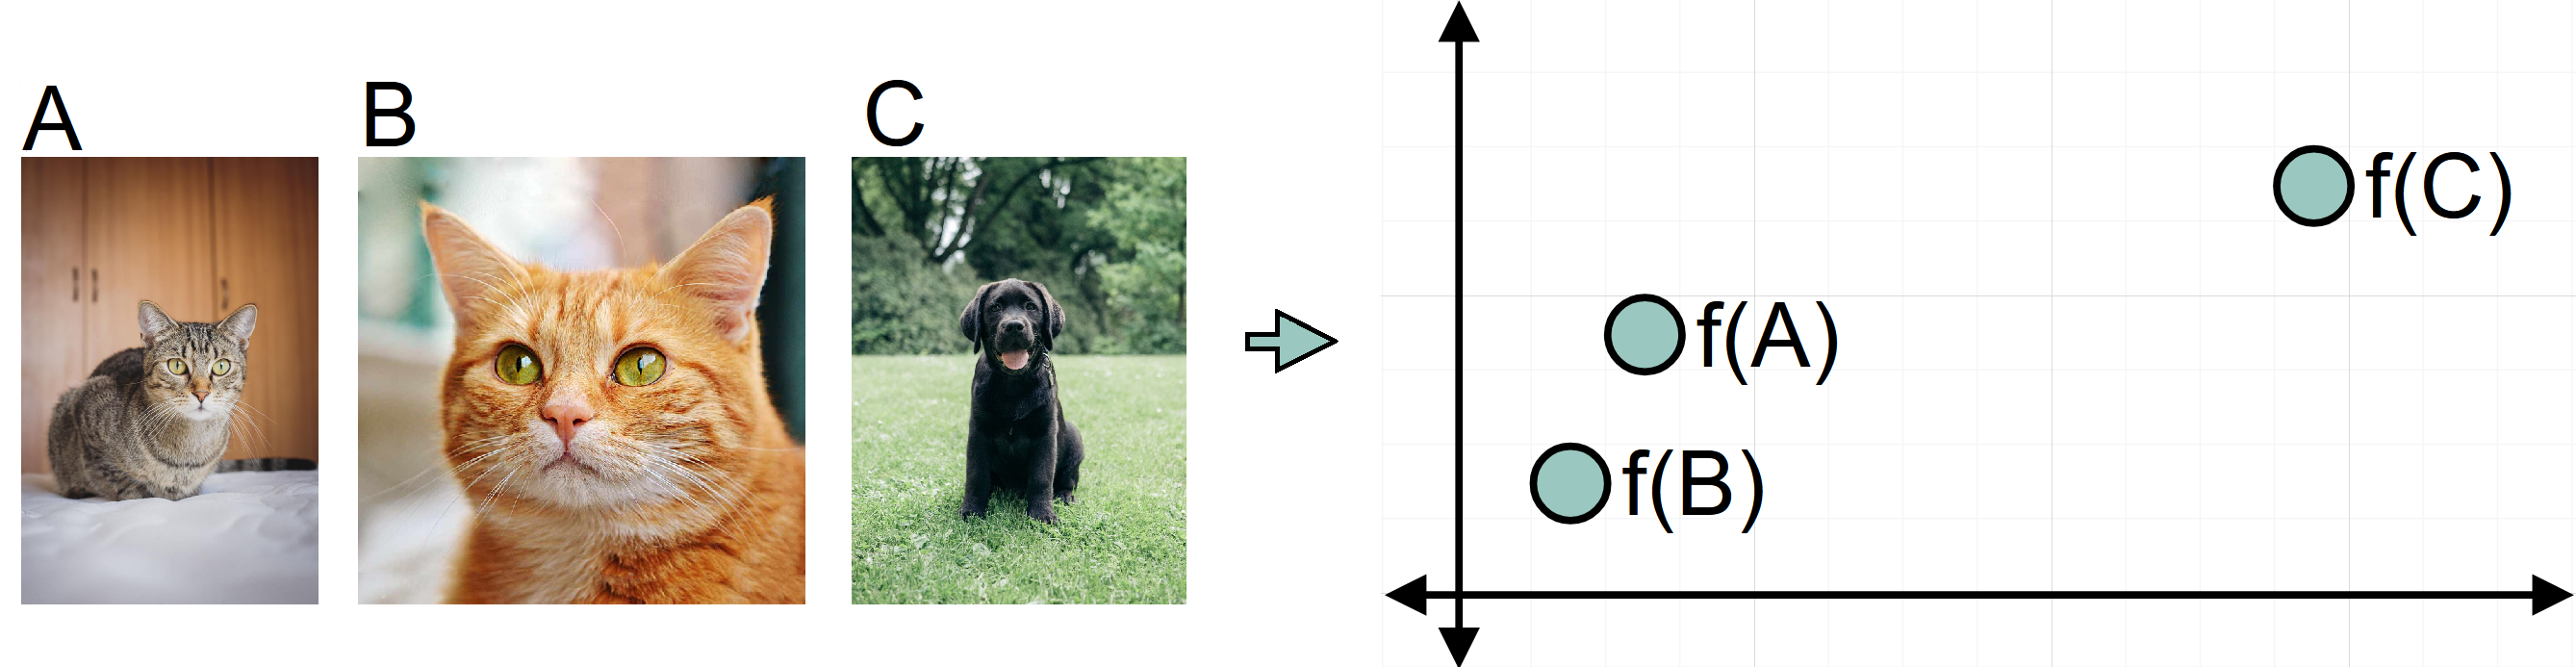

- a similarity score (e.g., cosine similarity) between embeddings ($f$) of the anchor $x$ and the positive ($x^+$) and negative ($x^-$) examples:
    $$sim(f(x), f(x^+)) >> sim(f(x), f(x^-))$$
    
- Main components: Data Sampling and Objective Optimization

$^1$ S. Chopra, R. Hadsell, and Y. LeCun. 2005. [Learning a similarity metric discriminatively, with application to face verification](https://doi.org/10.1109/CVPR.2005.202). In _2005 IEEE Computer Society Conference on Computer Vision and Pattern Recognition (CVPR’05)_, volume 1, pages 539–546

### Contrastive Objective Optimization
To transform the embedding space based on similarity, we have several similarity and loss metrics at our disposal. For this, we first need _contrastive data_, i.e., positive and negative sample pairs, which in NLP can be created either:
- supervised (directly uses class labels of a given task)
- automated (synonym replacement, random deletion, back translation, ...)

**Losses**

- **Contrastive Loss:** Suppose that we have a pair of an anchor and sample text $(c_a, c_i)$ and a label $y=0$ for similar samples and $=1$ otherwise. A neural network $f$ encodes the inputs as embeddings $\mathbf{x}_a = f(c_a)$ and $\mathbf{x}_i = f(c_i)$.
    
    $$ L= \color{darkgreen}{ (1-y)\cdot ||\mathbf{x}_a-\mathbf{x}_i||^2} \color{black}+ \color{darkred}{y\cdot \max(0,m-||\mathbf{x}_a-\mathbf{x}_i||^2)}$$
    
   - $\color{darkgreen}{\blacksquare}$ minimize distance between the same class
   - $\color{darkred}{\blacksquare}$ maximize distance between different classes
   - $m$ = minimal distance threshold for dissimilar samples (enforce that negative samples are at least at distance $m$)
    
- **Triplet Loss:** Instead of using an anchor with one positive or negative sample, use triplets including both for faster convergence of (usually) more stable embeddings. Suppose that we have a triplet $(c_a, c_p, c_n)$ with an anchor, positive, and negative sample, and embeddings $\mathbf{x}_a=f(c_a)$, $\mathbf{x}_p=f(c_p)$, and $\mathbf{x}_n=f(c_n)$.

    $$ L= \max(0, \color{darkgreen}{||\mathbf{x}_a-\mathbf{x}_p||^2} \color{darkred}{ - ||\mathbf{x}_a-\mathbf{x}_n|| ^2 } \color{black}{+ m)} $$

  - $\color{darkgreen}{\blacksquare}$ minimize distance between anchor and positive sample
  - $\color{darkred}{\blacksquare}$ maximize distance between anchor and negative sample
  - $m$ = minimal distance threshold for dissimilar samples (enforce that the negative sample is at least $m$ further away from the anchor than the positive sample)

- **N-pair Loss:** Generalizes Triplet Loss to multiple negative samples
- ...

## Data Structure

The dataset comes from the debate platform [*kialo*](https://www.kialo.com/).

- Each discussion starts with a _root claim_ to which users add arguments
- Users rate the _impact_ of a claim from 1 to 5

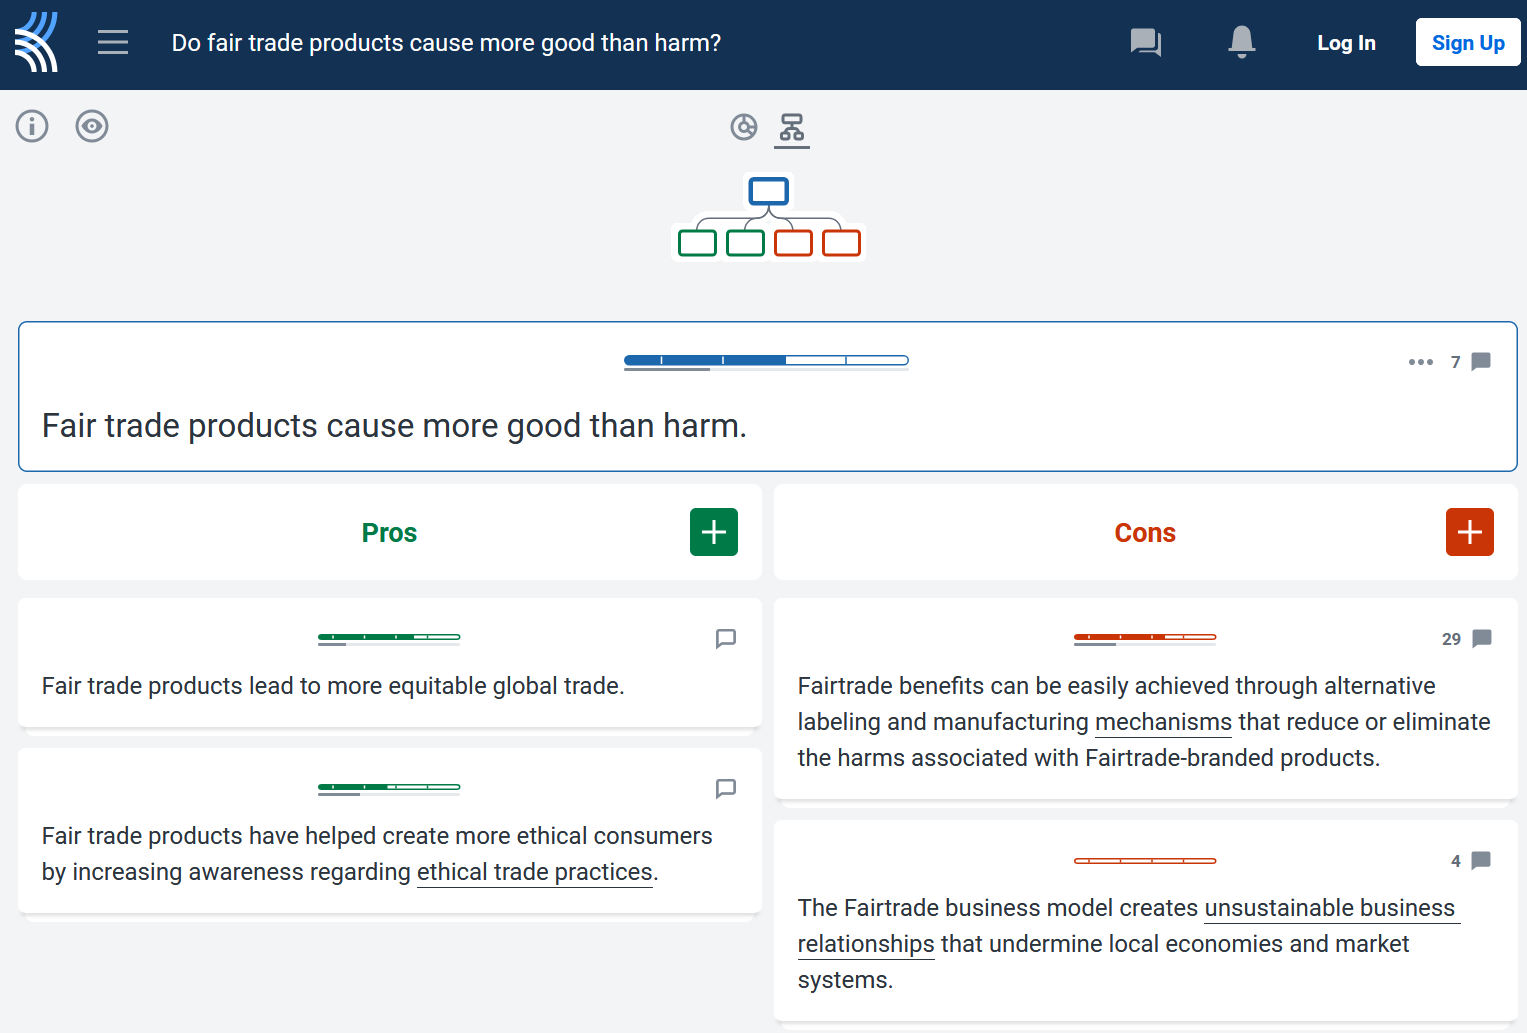

- Users add pros and cons to any existing arguments

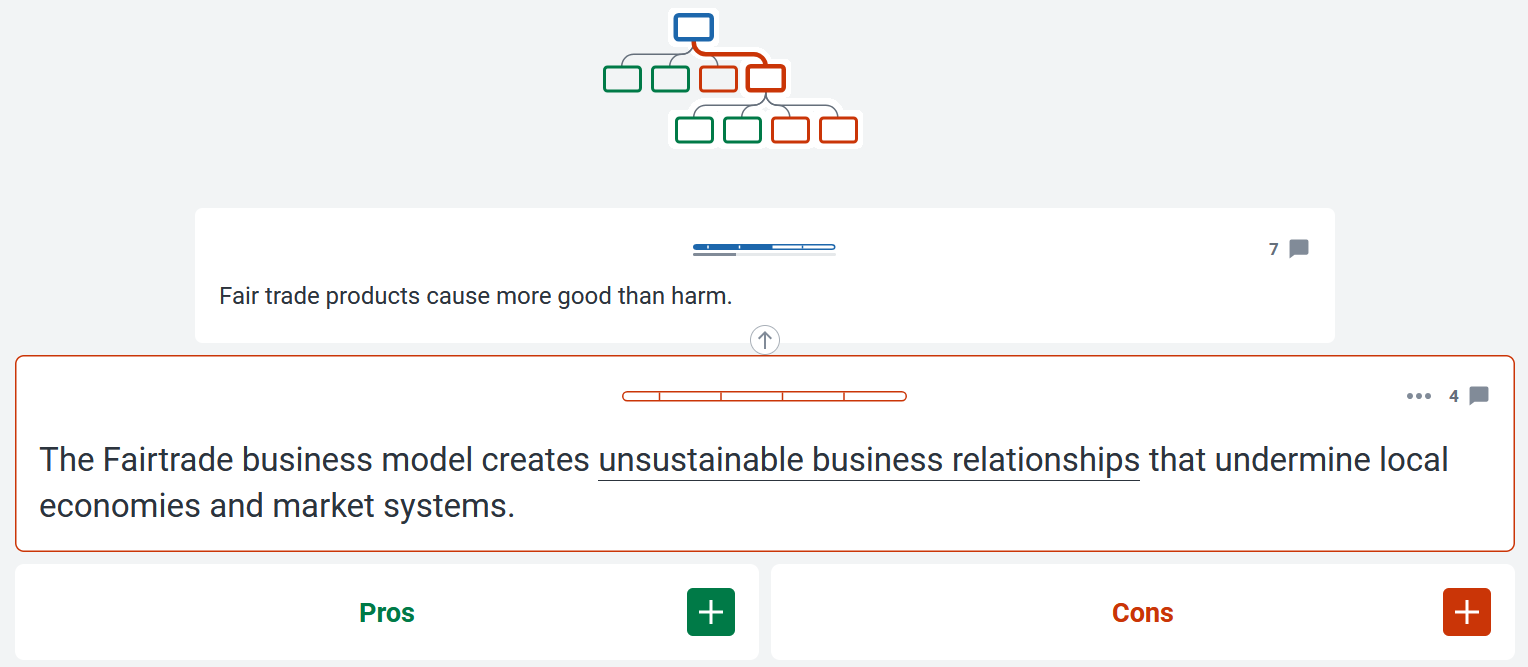

- Iteratively, this results in a discussion tree:

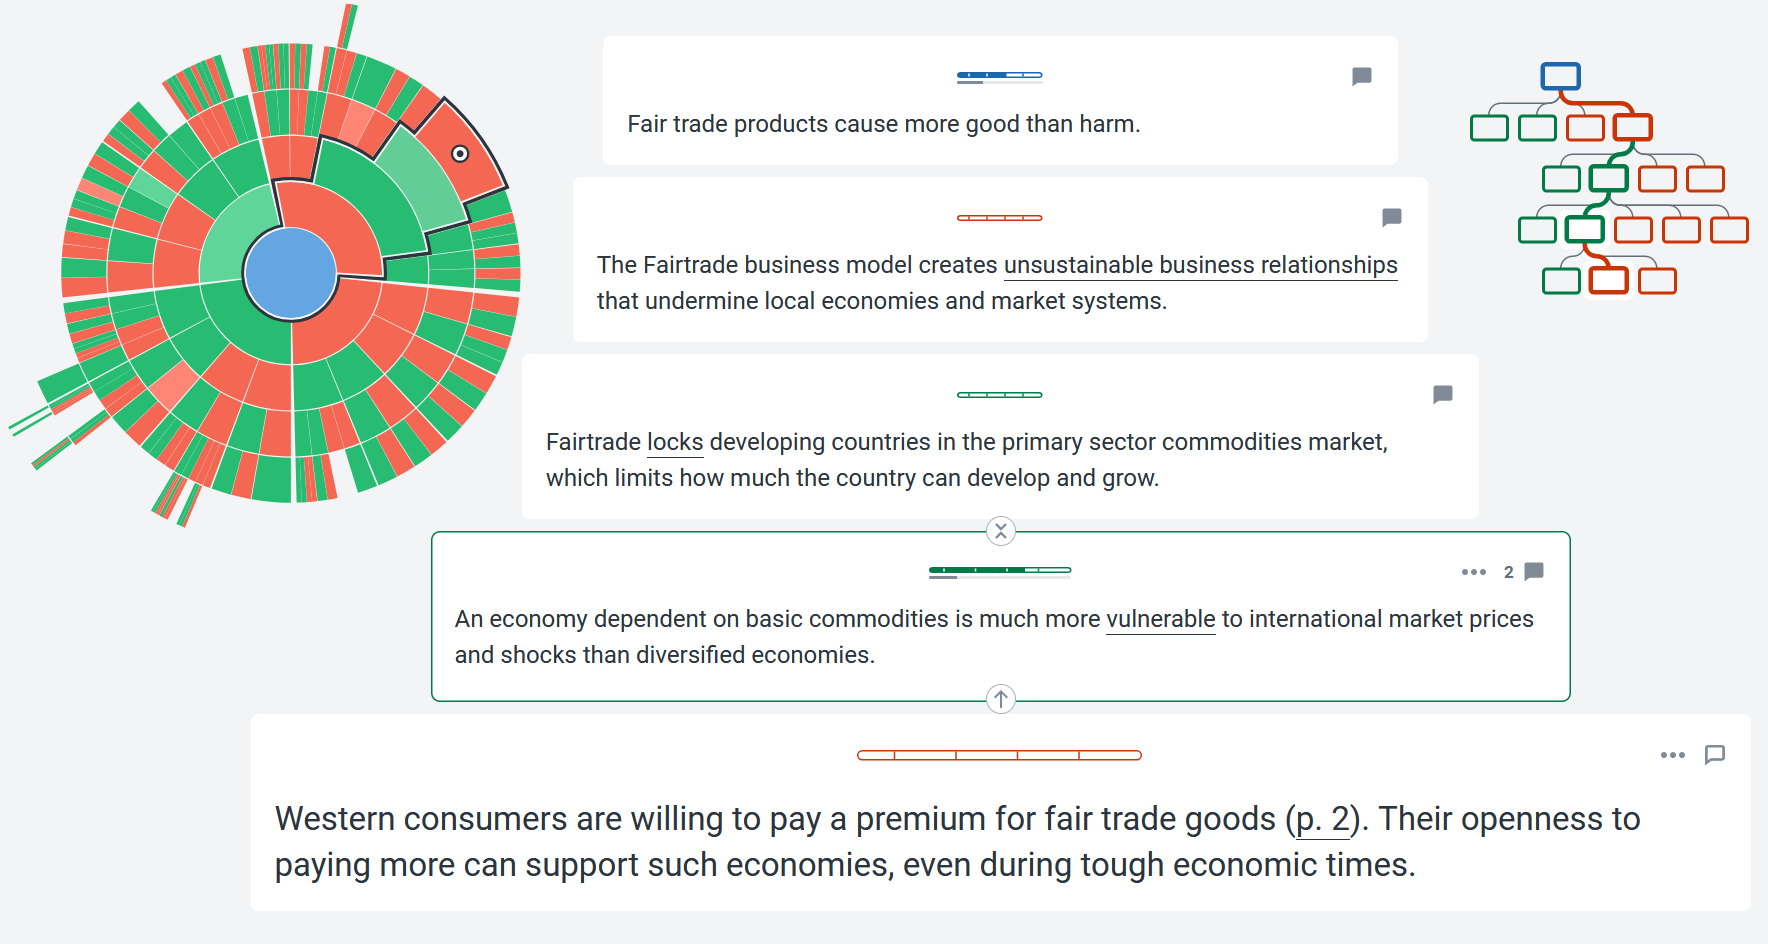

### Relationship extraction
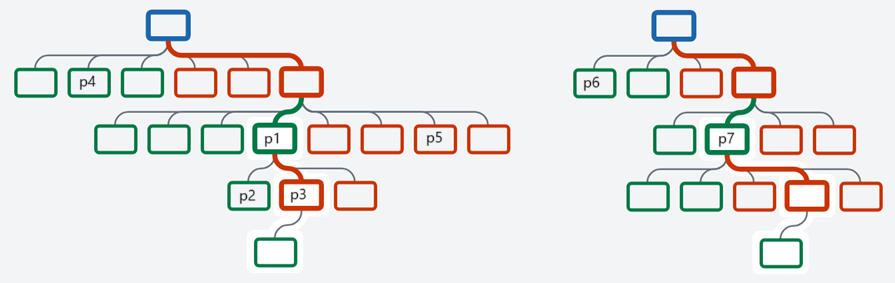

- _positive class_: $<p_2,p_1>$ (pos), $<p_3,p_1>$ (con)
- _negative class_: 
  - $<p_4,p_1>$, $<p_5,p_1>$ (same topic)
  - $<p_6,p_1>$, $<p_7,p_1>$ (different topic)

---

## 1 $-$ Contrastive Embeddings

<div style="text-align: right"><b>10 points</b></div>

Your main task in this assignment is to train a contrastive embedding model using the positive and negative samples from the given data.

### 1.1 $-$ Data Preparation

Before training the model, you must prepare your training and test data (**2 points**). The dataset is provided as a JSON file in `./data/claims.json` and includes:

- `parent_text`: parent (or anchor) text (proposition $p_1$ in the example above)
- `positive_text`: claim with a relation to the parent text ($p_2$, $p_3$)
- `negative_text_1`: unrelated claim from other debates ($p_6$, $p_7$)
- `negative_text_2`: unrelated claim from the same debate ($p_4$, $p_5$)
- `relation`: argumentative relation of the anchor to the `positive_text`, i.e., pro/con
- `split`: the data split the example belongs to, i.e., _train, validation, test_
- `id`/`debateId`/`parentId`: the unique ID of the anchor (`parent_text`) claim and of its parent claim and debate thread.

**Train data** $-$ Extract training instances according to the `split` feature from `./data/claims.json` to finetune a model as specified above. Include all possible pairs, i.e., three instances per anchor text: positive text, and both negative sampling strategies. Save the dataset in `./output/train_data.csv` with _only_ the columns:

- `positive`: the positive text,
- `negative`: a negative text, sampled from either the same or a different debate,
- `anchor`: the parent/anchor text,
- `sampling_strategy`: which text is used for `negative`, either _same_debate_, or _different_debate_,

**Validation and test data** $-$ Extract the validation and test instances according to the `split` feature from the original dataset and save them to `./output/validation_data.csv` and `./output/test_data.csv`, respectively. As this data is not used for triplet loss, each data point should be a single anchor-sample pair, i.e. the positive and negative pairs are separate instances. The dataset should thus only contain the columns:

- `anchor`: the parent/anchor text,
- `sample`: the sample text, either a positive, i.e., related claim, or a negative sample,
- `sampling_strategy`: which text is used for `negative`, either _same_debate_, or _different_debate_ (this field should be empty for positive samples),
- `label`: 0 or 1 (**Note:** the label direction (0 = unrelated and 1 = related claims).

For the next step, consult the [Huggingface tutorial](https://huggingface.co/docs/datasets/main/en/create_dataset\#from-python-dictionaries) to transform the data into a `Dataset` as required by the training method.

In [ ]:
data_path = "data/claims.json"

# YOUR CODE HERE
raise NotImplementedError

### 1.2 $-$ Model Training
You will now use the training and validation split to train contrastive embeddings using [Siamese Network Architecture](https://www.sbert.net/examples/sentence_transformer/training/sts/README.html) (**2 points**) and [Triplet Loss](https://www.sbert.net/docs/package_reference/sentence_transformer/losses.html#tripletloss) (**1 point**).

- Initialize the pretrained model from `modelpath`, where the checkpoint _all-mpnet-base-v2_ is saved. You can search for this model on Huggingface to learn more about the data and techniques used in its pretraining.
- Finetune your model for at least one epoch (**1 point**); one epoch is sufficient, but you may experiment further.
- Batch size and possible maximum input length (number of tokens) depend on the memory of the training GPU. Increasing the batch size speeds up training but needs more RAM. For your convenience, you should thus check and reset the model's `max_seq_length`, and find the maximum batch size you can fit on the GPU from `{4,8,16,32}`.
- For every 500 training steps, log the training progress (**1 point**) and validate the model on the _validation_ split with the `BinaryClassificationEvaluator` (**1 point**). **Note:** The Evaluator returns many different metrics. We are only interested in the $F_1$ score and the corresponding classification threshold. You may thus experiment with writing a wrapper function to extract only these metrics for the training logs.
- Use cosine distance for loss computation and cosine similarity with the evaluator and in the later evaluation tasks (**1 point**).
- Save your finetuned model in `./output/finetuned_model` (**1 point**).

In [ ]:
modelpath = '/bigwork/nhwpquec/argumentation-technology-25s/all-mpnet-base-v2/'

# YOUR CODE HERE
raise NotImplementedError

---

## 2 $-$ Evaluation

<div style="text-align: right"><b>10 points</b></div>

The base model you used in this assignment produces dense vector representations that are intended to capture the semantic information of the input sentence for downstream tasks like information retrieval or semantic clustering. 

By training the model for claim-relatedness, you transformed the embedding space so that, ideally, related claims are placed close together, and unrelated claims are further apart. However, similarity between two claims can arise for many different reasons. Two claims may:

- use similar vocabulary,
- discuss the same topic,
- express similar semantic content,
- or employ the same argumentative structure.
  
We therefore want to analyze the learned embedding space and compare it with a simpler surface similarity measure based on $tf\cdot idf$ representations. For this, you should load the test data you saved in task 1.1, and add all metrics to the same dataset.

### 2.1 $-$ Test Performance and Embedding Distance

Load your finetuned model and deploy it on the _test_ split to embed all sentences. You can now compute the embedding distance and, from this, classify the sentence pairs as related or unrelated based on a similarity threshold (**3 points**). 

- Use the same cosine similarity metric you used during training and with the BinaryClassificationEvaluator to calculate your scores.
- Add the similarity scores to the test data in a new column `embedding_similarity`.
- Use the corresponding threshold from the BinaryClassificationEvaluator to convert the scores into a binary judgment.
- Add the classification results to the test data in a new column `predicted_label`.

In [ ]:
test_data = pd.read_csv("output/test_data.csv")

# YOUR CODE HERE
raise NotImplementedError

In [ ]:
assert isinstance(test_data,pd.DataFrame)


### 2.2 $-$ Surface Similarity

$tf\cdot idf$ (term frequency - inverse document frequency) is a statistical text representation that assigns each document a sparse vector based on the words it contains. In contrast to neural embeddings, these vectors do not model semantic meaning or argumentative structure directly. Instead, they represent documents through weighted lexical overlap.

The idea behind $tf\cdot idf$ is to increase the importance of words that are frequent in a specific document but uncommon across the corpus as a whole. Common words that occur in almost all documents therefore receive lower weights, while more characteristic words receive higher weights. Assume we have four sentences:

$$\begin{align}
s_1 &= \textrm{`the movie was amazing'}\\
s_2 &= \textrm{`the movie was boring'}\\
s_3 &= \textrm{`the movie was long'}\\
s_4 &= \textrm{`the cats were amazing'}
\end{align}$$

The $tf\cdot idf$ of a term $o$ with frequency $tf(o, d)$ in a text document $d$ is defined as follows:


$$
\begin{align}
tf\cdot idf(o, d) &:= tf (o, d) \cdot idf (o, D)\\
tf(o, d) &= \frac{\#(o,d)}{\Sigma_{o_i \in d} \# (o_i, d)}\\
idf(t, D) &= log\left(\frac{\#(d,D)}{\#(d\in D : o\in d)}\right)\\
\end{align}
$$

where 
- $\#(o,d)$ is the frequency of the term $o$ in the document $d$
- $\Sigma_{o_i \in d} \# (o_i, d)$ is the total number of terms in the document $d$, i.e., its length
- $D$ is a collection of text documents
- $\#(d,D)$ is the number of text documents in the corpus
- $\#(d\in D : o\in d)$ the number of documents containing the term $t$.

Let us calculate two example values for the word _amazing_ and the word _the_ in document $s_1$:
- _amazing_
  - is one of four words in the sentence, so $tf(amazing, s_1) = \frac{1}{4} = 0.25$
  - occurs in 2 out of 4 documents, so $idf(amazing, D) = \log(\frac{4}{2}) \approx 0.693$
  - $tf\cdot idf(amazing, s_1) ) 0.25 \cdot 0.693 = 0.173$
- _the_
  - is one of four words in the sentence, so $tf(the, s_1) = \frac{1}{4} = 0.25$
  - however, it occurs in all documents, so $idf(the, D) = \log(\frac{4}{4}) = 0$
  - $tf\cdot idf(the, s_1) ) 0.25 \cdot 0 = 0$

Thus, while both terms appear once in $s_1$, $tf\cdot idf$ down-weights the very common word _the_ and highlights the distinctive word _amazing_. This simple adjustment makes the representation far more informative and discriminative than raw term frequencies. 

You do not need to implement the $tf\cdot idf$ calculation manually. Instead, use the [`TfidfVectorizer` implementation from sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html).

- Use the vectorizer to generate a $tf\cdot idf$ representation for all claims (i.e., all instances from `anchor`and `sample`) in the test dataset. Remove stopwords during tf-idf calculation (**2 points**).
- Use the same cosine similarity metric as before to calculate the similarity between the $tf\cdot idf$ representations of each sentence pair and add it to the test data in a new column `tfidf_similarity` (**1 point**).

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# YOUR CODE HERE
raise NotImplementedError

### 2.3 $-$ Analysis Preparations

Given your enriched test dataset, you should now prepare tables and visualizations for your analysis.

- First, generate a table to report the classification precision, recall, and $F_1$, as well as the average similarity of embeddings and $tf\cdot idf$ vectors for the three types of claim pairs: related pairs, unrelated/same-topic pairs, unrelated/different-topic pairs (**1 point**).
- Second, plot the distribution of similarity scores for all types of claim pairs and both text representations (**2 points**).
    - For each representation (trained embeddings or $tf\cdot idf$), generate one plot containing histograms of the similarity scores of all three types of claim pairs.
    - The plot should include a key for the three different histograms, which should be distinguished by color.
    - The two plots should include plot titles and axis descriptions, and can be created as side-by-side subfigures or individual figures.
    - Save your plot in the output folder to load it in task 3.
- Third, to illustrate your quantitative analysis, select one false positive (i.e., unrelated pair classified as related) with high embedding similarity and one false negative with low embedding similarity (**1 point**). For both examples, note down
    - the two claims,
    - the gold label,
    - the predicted label,
    - the embedding similarity,
    - the TF-IDF cosine similarity.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# YOUR CODE HERE
raise NotImplementedError

---

## 3 $-$ Discussion
<div style="text-align: right"><b>10 points</b></div>

Use your results from task 2 to analyze and interpret the embedding model's behavior. For all subtasks below, your answers should generally follow the structure:

1. **Claim** $-$ Verbalize and summarize the overall findings from the subtask (**2 points**).
2. **Evidence** $-$ Include specific numbers from task 2. Copy the markdown table from 2.1 into your answer here (**1 point**).
3. **Interpretation** $-$ Reason about why this observation might be happening and what it may mean about persuasive behavior (**2 points**).

### 3.1 $-$ Similarity and Pair Structure

Analyze how the three gold pair types differ with respect to embedding similarity, $tf\cdot idf$ similarity, and classification performance.
Discuss which pair types can be separated cleanly, which pair types overlap strongly, and how these overlaps relate to the observed classification performance.

Use your selected false positive and false negative examples to support your observations where appropriate.


YOUR ANSWER HERE

### 3.2 $-$ Lexical Similarity and Argumentative Relatedness
Analyze what the similarity of your trained embeddings and the $tf\cdot idf$ similarity appear to capture about the claim pairs.
Discuss when lexical overlap corresponds or does not correspond to argumentative relatedness, and how the embedding similarities differ from the $tf\cdot idf$ similarities in such cases.

Use your selected false positive and false negative examples to support your discussion where appropriate.

YOUR ANSWER HERE